In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchcvnn.nn as c_nn
import torch.optim as optim
import random
import copy
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, Subset
from torchcvnn.datasets import ALOSDataset, Bretigny, PolSFDataset, S1SLC, MSTARTargets
from typing import List, Optional, Tuple, Union, Any
from tqdm import tqdm
from pathlib import Path
from PIL import Image

In [2]:
print(f"Interpréteur utilisé : {sys.executable}")

Interpréteur utilisé : /home/nicolas/Documents/ProjetSegmentation/.venv/bin/python


In [3]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, size, act_choice="crelu", norm_choice="bn2d"):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False, dtype=torch.complex64),
            self._get_norm(norm_choice, out_channels, size),
            self._get_act(act_choice),
            
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False, dtype=torch.complex64),
            self._get_norm(norm_choice, out_channels, size),
            self._get_act(act_choice)
        )

    def _get_act(self, choice):
        if choice == "crelu": return c_nn.CReLU()
        elif choice == "modrelu": return c_nn.modReLU()
        elif choice == "zrelu": return c_nn.zReLU()
        elif choice == "cardioid": return c_nn.Cardioid()
        else: return c_nn.CReLU() 

    def _get_norm(self, choice, channels, size):
        if choice == "bn1d": return c_nn.BatchNorm1d(channels) 
        elif choice == "bn2d": return c_nn.BatchNorm2d(channels)
        elif choice == "ln": return c_nn.LayerNorm([channels, size, size])
        elif choice == "rms": return c_nn.RMSNorm(size)
        else: return nn.Identity()

    def forward(self, x):
        return self.double_conv(x)

In [4]:
class Encoder(nn.Module):
    def __init__(self, in_channels, start_size, encoder_config):
        super().__init__()
        self.layers = nn.ModuleList()
        
        print("\n" + "="*40)
        print("🛠️ CONFIGURATION AUTOMATIQUE DE L'ENCODEUR")
        print("="*40)
        
        self.nbLayer = len(encoder_config)
        current_size = start_size
        current_in_channels = in_channels
        
        
        self.out_channels_list = [] #On sauvegarde la liste des canaux pour la donner au décodeur plus tard

        for i, layer_cfg in enumerate(encoder_config):
            # Lecture sécurisée du dictionnaire (avec des valeurs par défaut intelligentes)
            out_channels = layer_cfg["out_channels"]
            act_choice = layer_cfg.get("act", "crelu")
            norm_choice = layer_cfg.get("norm", "bn2d")
            pool_choice = layer_cfg.get("pool", "max") # Par défaut on fait un max pooling

            print(f"[Bilan Layer {i+1}] : {current_in_channels} -> {out_channels} canaux | Taille prévue : {current_size}x{current_size} | Pool: {pool_choice}")

            layer_block = nn.ModuleDict({
                "conv": DoubleConv(current_in_channels, out_channels, current_size, act_choice, norm_choice),
                "pool": self._get_pool(pool_choice, channels=out_channels) 
            })
            self.layers.append(layer_block)
            
            # On enregistre le nombre de canaux de ce pont
            self.out_channels_list.append(out_channels)

            # Mise à jour des variables pour la couche suivante
            current_in_channels = out_channels
            
            # J'ai ajouté "strided" ici car un stride de 2 divise aussi l'image par 2 !
            if pool_choice in ["max", "avg", "strided"]:
                current_size //= 2

    def _get_pool(self, choice, channels):
        if choice == "max": return c_nn.MaxPool2d(kernel_size=2, stride=2)
        elif choice == "avg": return c_nn.AvgPool2d(kernel_size=2, stride=2)
        elif choice == "strided":  
           return nn.Conv2d(channels, channels, kernel_size=2, stride=2, dtype=torch.complex64) # in_channels = out_channels = channels (on ne change que l'espace, pas la profondeur)
        else: 
            return nn.Identity()

    def forward(self, x, verbose=False):
        skip_connections = []
        
        if verbose: print(f"\n[ENCODEUR] Entrée initiale : {x.shape}")
        
        for i, layer in enumerate(self.layers):
            x = layer["conv"](x)
            skip_connections.append(x)
            
            if verbose: print(f"  Layer {i+1} (après conv) : {x.shape}  <-- Sauvegardé pour le pont")
            x = layer["pool"](x)
            
            if verbose and layer["pool"].__class__.__name__ != "Identity": 
                print(f"   ⬇ Layer {i+1} (après pool) : {x.shape}")
                
        return x, skip_connections

In [5]:
class CustomUp(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels, size, act_choice="crelu", norm_choice="bn2d"):
        super().__init__()
        
        up_out_channels = in_channels // 2 
        self.up = nn.ConvTranspose2d(in_channels, up_out_channels, kernel_size=2, stride=2, dtype=torch.complex64)
        
        cat_channels = up_out_channels + skip_channels
        self.conv = DoubleConv(cat_channels, out_channels, size * 2, act_choice, norm_choice)

    def forward(self, x, skip_x):
        x = self.up(x)
        diffY = skip_x.size()[2] - x.size()[2]
        diffX = skip_x.size()[3] - x.size()[3]
        x = F.pad(x, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([skip_x, x], dim=1)
        return self.conv(x)

In [6]:
class Decoder(nn.Module):
    def __init__(self, channels_list, bottom_size, decoder_config):
        super().__init__()
        
        self.layers = nn.ModuleList()
        
        print("\n" + "="*40)
        print("CONFIGURATION AUTOMATIQUE DU DÉCODEUR")
        print("="*40)
        
        current_size = bottom_size
        in_channels = channels_list[0] #Prend le tout premier élément (ici 128). C'est le "fond" du U-Net (le Bottleneck)
        skips_channels = channels_list[1:] #liste du nombre de canaux (l'épaisseur) de chacun de ces ponts avec le [1:] = Prends tout le reste de la liste, du 2ème élément jusqu'à la fin
        
        #On s'assure qu'on a bien fourni autant de configurations que de ponts
        assert len(skips_channels) == len(decoder_config), \
            f"Erreur : L'encodeur a {len(skips_channels)} ponts, mais la config du décodeur a {len(decoder_config)} étages !"
        
        #On utilise zip() pour parcourir les ponts ET la config en même temps
        for i, (skip_chan, layer_cfg) in enumerate(zip(skips_channels, decoder_config)):
            print(f"\n--- Up Layer {i+1} (Cible spatiale : {current_size * 2}x{current_size * 2}) ---")
            print(f"   (Info : Fusion de {in_channels//2} canaux remontés + {skip_chan} canaux du pont)")
            
            # LECTURE DU DICTIONNAIRE 
            out_channels = layer_cfg["out_channels"]
            act_choice = layer_cfg.get("act", "crelu") # .get("cle", "valeur_par_defaut") permet d'éviter que le code plante si tu oublies un mot dans ton dictionnaire
            norm_choice = layer_cfg.get("norm", "bn2d")
            
            print(f"[Bilan Up Layer {i+1}] : {in_channels//2 + skip_chan} -> {out_channels} canaux | Taille : {current_size*2}x{current_size*2}")
            
            self.layers.append(CustomUp(
                in_channels=in_channels, 
                skip_channels=skip_chan, 
                out_channels=out_channels, 
                size=current_size, 
                act_choice=act_choice, 
                norm_choice=norm_choice
            ))
            
            in_channels = out_channels
            current_size *= 2
            
        self.final_out_channels = in_channels


    def forward(self, x, skip_connections, verbose=False):
        skip_connections = skip_connections[::-1] #Inversion de la liste afin de remonter avec les bonne tailles des images dans l'ordre
        if verbose: print(f"\n[DÉCODEUR] Fond du U-Net (Bottleneck) : {x.shape}")
        
        for i, layer in enumerate(self.layers):
            x = layer(x, skip_connections[i])
            if verbose: print(f"Up Layer {i+1} (après fusion & conv) : {x.shape}")
            
        return x

In [7]:
class UNet(nn.Module):
    def __init__(self, config):
        super().__init__()
        
        print("\n" + "*"*80)
        print(" INITIALISATION DU U-NET COMPLET ")
        print("*"*80)

        # 1. Extraction des variables globales
        in_channels = config["in_channels"]
        num_classes = config["num_classes"]
        start_size = config["start_size"]
        enc_cfg = config["encoder_config"]
        dec_cfg = config["decoder_config"]

        # 2. Création de l'Encodeur
        self.encoder = Encoder(
            in_channels=in_channels,
            start_size=start_size,
            encoder_config=enc_cfg
        )

        # 3. Calcul intelligent du "Bottom Size" (Taille au fond du U-Net)- On regarde la configuration de l'encodeur pour savoir combien de fois l'image a été réduite
        bottom_size = start_size
        for layer in enc_cfg:
            pool_type = layer.get("pool", "max")
            if pool_type in ["max", "avg", "strided"]:
                bottom_size //= 2
                
        print(f"\n[INFO U-NET] L'image atteindra une taille minimale de {bottom_size}x{bottom_size} au fond du réseau.")

        # 4. Création du Décodeur
        self.decoder = Decoder(
            channels_list=self.encoder.out_channels_list[::-1], # On inverse la liste de l'encodeur !
            bottom_size=bottom_size,
            decoder_config=dec_cfg
        )

        # 5. La Couche Finale (Classification) - Elle prend les canaux finaux du décodeur et les transforme en "num_classes" (ex: 7 pour San Francisco)
        self.final_conv = nn.Conv2d(
            in_channels=self.decoder.final_out_channels,
            out_channels=num_classes,
            kernel_size=1,
            dtype=torch.complex64  
        )

    def forward(self, x, verbose=False):
        if verbose: print("\n[U-NET] === DÉBUT DU FORWARD ===")
        
        # Étape 1 : La Descente
        x, skip_connections = self.encoder(x, verbose=verbose)
        
        # On retire le Bottleneck de la liste des ponts !
        skip_connections = skip_connections[:-1]  #Prends toute la liste du début, jusqu'à l'avant-dernier élément (inclus), et jette le tout dernier"
        
        # Étape 2 : La Remontée
        x = self.decoder(x, skip_connections, verbose=verbose)
        
        # Étape 3 : La Décision
        x = self.final_conv(x)
        
        if verbose: 
            print(f"\n[U-NET] Sortie finale (Logits) : {x.shape}")
            print("[U-NET] === FIN DU FORWARD ===\n")
            
        return x

In [8]:
ma_config_polsar = {
    "in_channels": 4,      # HH, HV, VH, VV
    "num_classes": 7,      # Tes 7 classes (Océan, Végétation, Bâtiments, etc.)
    "start_size": 256,     # La taille de tes patchs
    
    "encoder_config": [
        {"out_channels": 32, "act": "crelu", "norm": "bn2d", "pool": "strided"},
        {"out_channels": 64, "act": "crelu", "norm": "bn2d", "pool": "strided"},
        {"out_channels": 128, "act": "crelu", "norm": "bn2d", "pool": "none"} # Le fond (pas de pooling)
    ],
    
    "decoder_config": [
        {"out_channels": 64, "act": "crelu", "norm": "bn2d"},
        {"out_channels": 32, "act": "crelu", "norm": "bn2d"}
    ]
}


mon_modele_final = UNet(ma_config_polsar) #Instanciation
print("\n--- CRASH TEST ---")
tenseur_test = torch.randn(4, 4, 256, 256, dtype=torch.complex64) # Batch de 4 images
sortie = mon_modele_final(tenseur_test, verbose=True)


********************************************************************************
 INITIALISATION DU U-NET COMPLET 
********************************************************************************

🛠️ CONFIGURATION AUTOMATIQUE DE L'ENCODEUR
[Bilan Layer 1] : 4 -> 32 canaux | Taille prévue : 256x256 | Pool: strided
[Bilan Layer 2] : 32 -> 64 canaux | Taille prévue : 128x128 | Pool: strided
[Bilan Layer 3] : 64 -> 128 canaux | Taille prévue : 64x64 | Pool: none

[INFO U-NET] L'image atteindra une taille minimale de 64x64 au fond du réseau.

CONFIGURATION AUTOMATIQUE DU DÉCODEUR

--- Up Layer 1 (Cible spatiale : 128x128) ---
   (Info : Fusion de 64 canaux remontés + 64 canaux du pont)
[Bilan Up Layer 1] : 128 -> 64 canaux | Taille : 128x128

--- Up Layer 2 (Cible spatiale : 256x256) ---
   (Info : Fusion de 32 canaux remontés + 32 canaux du pont)
[Bilan Up Layer 2] : 64 -> 32 canaux | Taille : 256x256

--- CRASH TEST ---

[U-NET] === DÉBUT DU FORWARD ===

[ENCODEUR] Entrée initiale : torc

In [9]:
# --- 1. GESTION DES CHEMINS ---
project_root = os.path.abspath('..')

# Ajout de cvnn/src au système pour importer le code de Quentin
chemin_module = os.path.join(project_root, 'cvnn', 'src')
if chemin_module not in sys.path:
    sys.path.append(chemin_module)

from cvnn.data import get_dataloaders

# --- 2. CONFIGURATION PARFAITE ---
cfg = {
    "task": "segmentation",
    "data": {
        # LES DEUX LIGNES MAGIQUES QUI MANQUAIENT
        "type": "polsar",       # Déclenche la fusion du dictionnaire dans cvnn
        "num_channels": 4,      # HH, HV, VH, VV
        
        "dataset": {
            "name": "PolSFDataset",
            "trainpath": os.path.join(project_root, "data", "PolSF"),
            "has_labels": True,
            "patch_size": 32,
            "patch_stride": 32
        },
        # On laisse vide ! transform_registry.py va tout faire automatiquement.
        "transforms": [], 
        
        "batch_size": 4,
        "shuffle": True,
        "valid_ratio": 0.2,
        "test_ratio": 0.1,
        "num_workers": 0,
        "recompute_statistics": False
    },
    "model": {
        "layer_mode": "complex" 
    }
}

# --- 3. CHARGEMENT DES DONNÉES ---
print("Chargement des données PolSAR en cours...")
loaders = get_dataloaders(cfg, use_cuda=torch.cuda.is_available())

if len(loaders) == 3:
    train_loader, valid_loader, test_loader = loaders
    print("Succès ! Les 3 jeux de données (Train/Valid/Test) sont prêts.")
else:
    train_loader, valid_loader = loaders
    test_loader = None
    print("Seulement 2 loaders créés (Train, Valid).")

# --- 4. CRASH TEST ---
print("\n🔍 Extraction du premier batch d'entraînement...")
x_batch, y_batch = next(iter(train_loader))

print(f"   - Tenseur Image (X)  : {x_batch.shape} | Type : {x_batch.dtype}")
print(f"   - Tenseur Labels (Y) : {y_batch.shape} | Type : {y_batch.dtype}")

if x_batch.is_complex():
    print(" VICTOIRE : Les données radar sont bien en format Complexe !")

2026-04-01 16:13:40,763 - cvnn.data - INFO - Using label-based clustering split
2026-04-01 16:13:40,763 - cvnn.data_splitting - INFO - Extracting labels for clustering-based split...


Chargement des données PolSAR en cours...


2026-04-01 16:13:57,185 - cvnn.data_splitting - INFO - Found 7 classes: [np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6)]
2026-04-01 16:13:57,361 - cvnn.data_splitting - INFO - Multilabel stratified segmentation split: train=9611, valid=2734, test=1401


Succès ! Les 3 jeux de données (Train/Valid/Test) sont prêts.

🔍 Extraction du premier batch d'entraînement...
   - Tenseur Image (X)  : torch.Size([4, 4, 32, 32]) | Type : torch.complex64
   - Tenseur Labels (Y) : torch.Size([4, 32, 32]) | Type : torch.uint8
 VICTOIRE : Les données radar sont bien en format Complexe !


In [10]:
if test_loader is not None:
    print("Lancement du test sur le Test Loader...")
    
    # Récupération d'un batch de test
    x_test, y_test = next(iter(test_loader))
    
    print(f"Forme des images de TEST (X) : {x_test.shape}") # Doit être [4, 3, 256, 256]
    print(f"Forme des labels de TEST (Y) : {y_test.shape}") # Doit être [4, 256, 256]
    print(f"Type des données : {x_test.dtype}")

Lancement du test sur le Test Loader...
Forme des images de TEST (X) : torch.Size([4, 4, 32, 32])
Forme des labels de TEST (Y) : torch.Size([4, 32, 32])
Type des données : torch.complex64


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt # NOUVEAU : Pour dessiner les courbes
from tqdm import tqdm
from cvnn.losses import FocalLoss

# --- 1. PRÉPARATION ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Entraînement lancé sur : {device}")

model = mon_modele_final.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

criterion = FocalLoss(
    gamma=2.0,                 
    ignore_index=0,            
    use_class_weights=True,    
    weight_mode="balanced"     
)

epochs = 50
best_valid_loss = float('inf')

#Création des listes pour stocker l'historique
history_train_loss = []
history_valid_loss = []

# --- 2. LA BOUCLE D'ENTRAÎNEMENT ---
for epoch in range(epochs):
    
    # === PHASE D'ENTRAÎNEMENT ===
    model.train()
    train_loss = 0.0
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [TRAIN]")
    
    for x_batch, y_batch in train_loop:
        x_batch = x_batch.to(device, dtype=torch.complex64)
        y_batch = y_batch.to(device, dtype=torch.long)
        
        optimizer.zero_grad()
        outputs = model(x_batch)
        outputs_real = torch.abs(outputs)
        
        loss = criterion(outputs_real, y_batch)
        
        if not torch.isnan(loss):
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_loop.set_postfix(loss=loss.item())
            
    avg_train_loss = train_loss / len(train_loader)
    
    # === PHASE DE VALIDATION ===
    model.eval()
    valid_loss = 0.0
    valid_loop = tqdm(valid_loader, desc=f"Epoch {epoch+1}/{epochs} [VALID]")
    
    with torch.no_grad():
        for x_batch, y_batch in valid_loop:
            x_batch = x_batch.to(device, dtype=torch.complex64)
            y_batch = y_batch.to(device, dtype=torch.long)
            
            outputs = model(x_batch)
            outputs_real = torch.abs(outputs)
            
            loss = criterion(outputs_real, y_batch)
            
            if not torch.isnan(loss):
                valid_loss += loss.item()
                valid_loop.set_postfix(loss=loss.item())
                
    avg_valid_loss = valid_loss / len(valid_loader)
    
    #On sauvegarde les moyennes de l'epoch dans nos listes
    history_train_loss.append(avg_train_loss)
    history_valid_loss.append(avg_valid_loss)
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Valid Loss: {avg_valid_loss:.4f}")
    
    # === SAUVEGARDE ===
    if avg_valid_loss < best_valid_loss and not torch.isnan(torch.tensor(avg_valid_loss)):
        best_valid_loss = avg_valid_loss
        torch.save(model.state_dict(), "meilleur_unet_polsar.pth")
        print("   Nouveau meilleur modèle sauvegardé !")

🚀 Entraînement lancé sur : cuda


Epoch 1/50 [VALID]: 100%|██████████| 684/684 [00:07<00:00, 89.06it/s, loss=7.03e-6] 


Epoch 1/50 | Train Loss: 0.0010 | Valid Loss: 0.0027
   Nouveau meilleur modèle sauvegardé !


Epoch 2/50 [VALID]: 100%|██████████| 684/684 [00:07<00:00, 87.74it/s, loss=0.000155]


Epoch 2/50 | Train Loss: 0.0024 | Valid Loss: 0.0049


...

Epoch 48/50 | Train Loss: 0.0006 | Valid Loss: 0.0015


Epoch 49/50 [VALID]: 100%|██████████| 684/684 [00:07<00:00, 86.66it/s, loss=4.18e-5] 


Epoch 49/50 | Train Loss: 0.0011 | Valid Loss: 0.0009
   Nouveau meilleur modèle sauvegardé !


Epoch 50/50 [VALID]: 100%|██████████| 684/684 [00:07<00:00, 88.46it/s, loss=2.8e-5]  

Epoch 50/50 | Train Loss: 0.0006 | Valid Loss: 0.0038



Génération du graphique des performances...


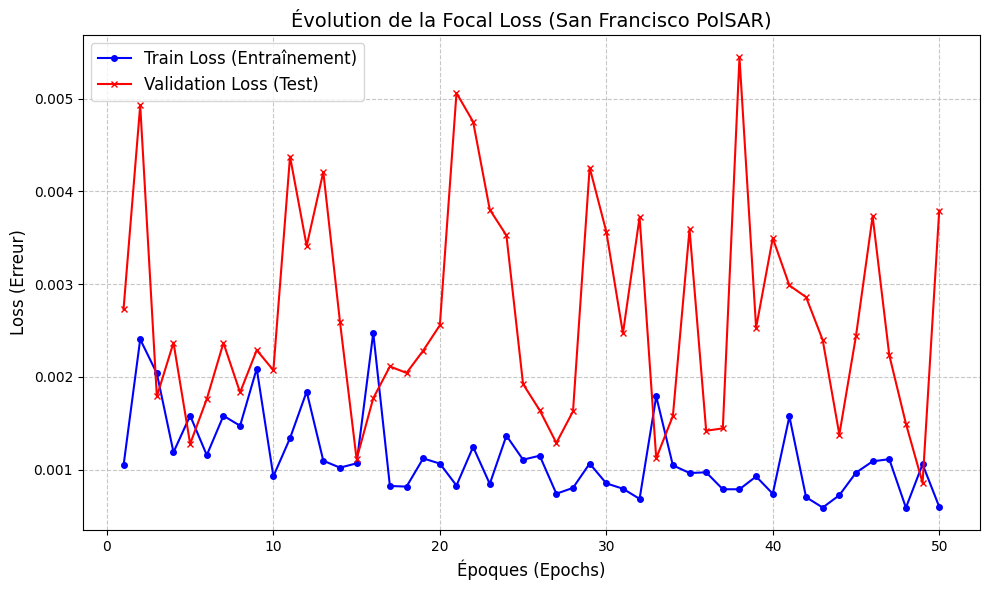

In [12]:
# --- 3. AFFICHAGE DES COURBES (À la fin des 50 epochs) ---
print("\nGénération du graphique des performances...")
plt.figure(figsize=(10, 6))

# On trace les deux courbes
plt.plot(range(1, epochs+1), history_train_loss, label='Train Loss (Entraînement)', color='blue', marker='o', markersize=4)
plt.plot(range(1, epochs+1), history_valid_loss, label='Validation Loss (Test)', color='red', marker='x', markersize=4)

# Habillage du graphique
plt.title('Évolution de la Focal Loss (San Francisco PolSAR)', fontsize=14)
plt.xlabel('Époques (Epochs)', fontsize=12)
plt.ylabel('Loss (Erreur)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

# Affichage propre dans le notebook
plt.tight_layout()
plt.show()

In [13]:
from cvnn.visualize import plot_segmentations

# --- 1. ÉVALUATION SUR LE JEU DE TEST ---
print("Début de l'évaluation sur le jeu de test...")

# On recharge le meilleur modèle sauvegardé (pour être sûr d'avoir les meilleurs poids)
model.load_state_dict(torch.load("meilleur_unet_polsar.pth"))
model.eval() # On passe en mode évaluation (désactive les gradients, fige les batch norms)

test_loss = 0.0
correct_pixels = 0
total_pixels = 0

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device, dtype=torch.complex64)
        y_batch = y_batch.to(device, dtype=torch.long)
        
        # Prédiction
        outputs = model(x_batch)
        outputs_real = torch.abs(outputs)
        
        # Calcul de la perte sur le test
        loss = criterion(outputs_real, y_batch)
        if not torch.isnan(loss):
            test_loss += loss.item()
            
        # Calcul de la précision (Accuracy) pixel par pixel
        # argmax(dim=1) permet de trouver la classe qui a la plus grande probabilité
        predictions = torch.argmax(outputs_real, dim=1) 
        
        # On ignore la classe 0 (le fond) pour calculer la précision
        mask = y_batch != 0
        correct_pixels += (predictions[mask] == y_batch[mask]).sum().item()
        total_pixels += mask.sum().item()

avg_test_loss = test_loss / len(test_loader)
test_accuracy = (correct_pixels / total_pixels) * 100 if total_pixels > 0 else 0

print(f"✅ Résultat final du Test :")
print(f"   - Loss moyenne : {avg_test_loss:.4f}")
print(f"   - Précision Globale (Accuracy) : {test_accuracy:.2f} %")

Début de l'évaluation sur le jeu de test...
✅ Résultat final du Test :
   - Loss moyenne : 0.0010
   - Précision Globale (Accuracy) : 82.94 %



🎨 Génération des images de segmentation...


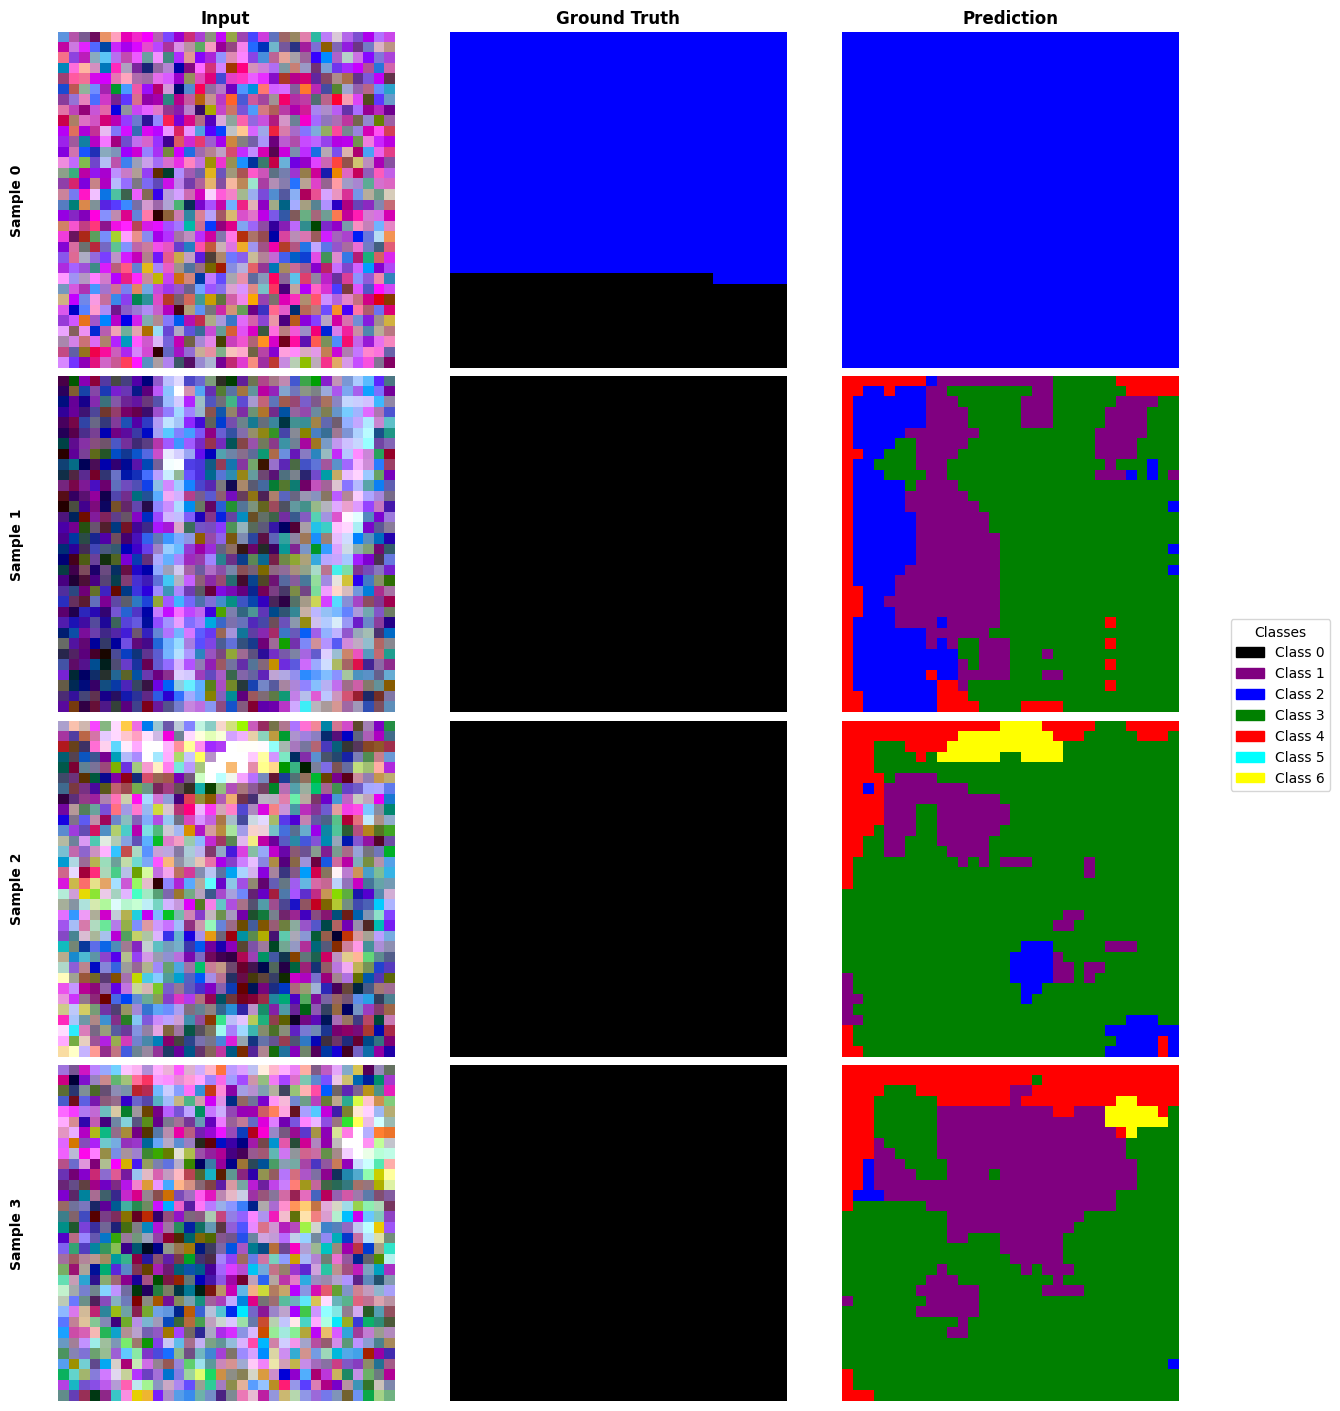

In [14]:
# --- 2. VISUALISATION DES RÉSULTATS ---
print("\n🎨 Génération des images de segmentation...")

# On extrait un seul batch du test_loader pour la visualisation
x_vis, y_vis = next(iter(test_loader))
x_vis = x_vis.to(device, dtype=torch.complex64)

# On fait prédire ce batch par le modèle
with torch.no_grad():
    outputs_vis = model(x_vis)
    preds_vis = torch.argmax(torch.abs(outputs_vis), dim=1)

# Pour l'affichage matplotlib, on doit ramener les tenseurs sur le CPU
x_vis_cpu = x_vis.cpu()
y_vis_cpu = y_vis.cpu()
preds_vis_cpu = preds_vis.cpu()

# Noms des classes pour San Francisco (à adapter si besoin)
class_names = [
    "Unclassified", "Ocean", "Urban (Dense)", "Vegetation", 
    "Urban (Sparse)", "Mountain", "Bare Soil"
]

# Appel de la fonction de QuentinGABOT
fig = plot_segmentations(
    inputs=x_vis_cpu,               # L'image radar complexe originale
    predictions=preds_vis_cpu,      # Les classes prédites par ton U-Net
    labels=y_vis_cpu,               # Les vraies classes (Ground Truth)
    dataset_type="polsar",          # Déclenche la transformation de Pauli automatiquement !
    number_classes=7,               # Utilise la palette de 7 couleurs prévue dans son code
    class_names=class_names,
    num_samples=4                   # Affiche les 4 images du batch
)

plt.show()

🗺️ Préparation de la reconstruction de la carte complète...
📏 Taille estimée de San Francisco : 5056 x 2784 pixels
⏳ Reconstitution de l'image en cours (le modèle scanne la baie de San Francisco)...
✅ Scan terminé ! Génération du dashboard visuel...


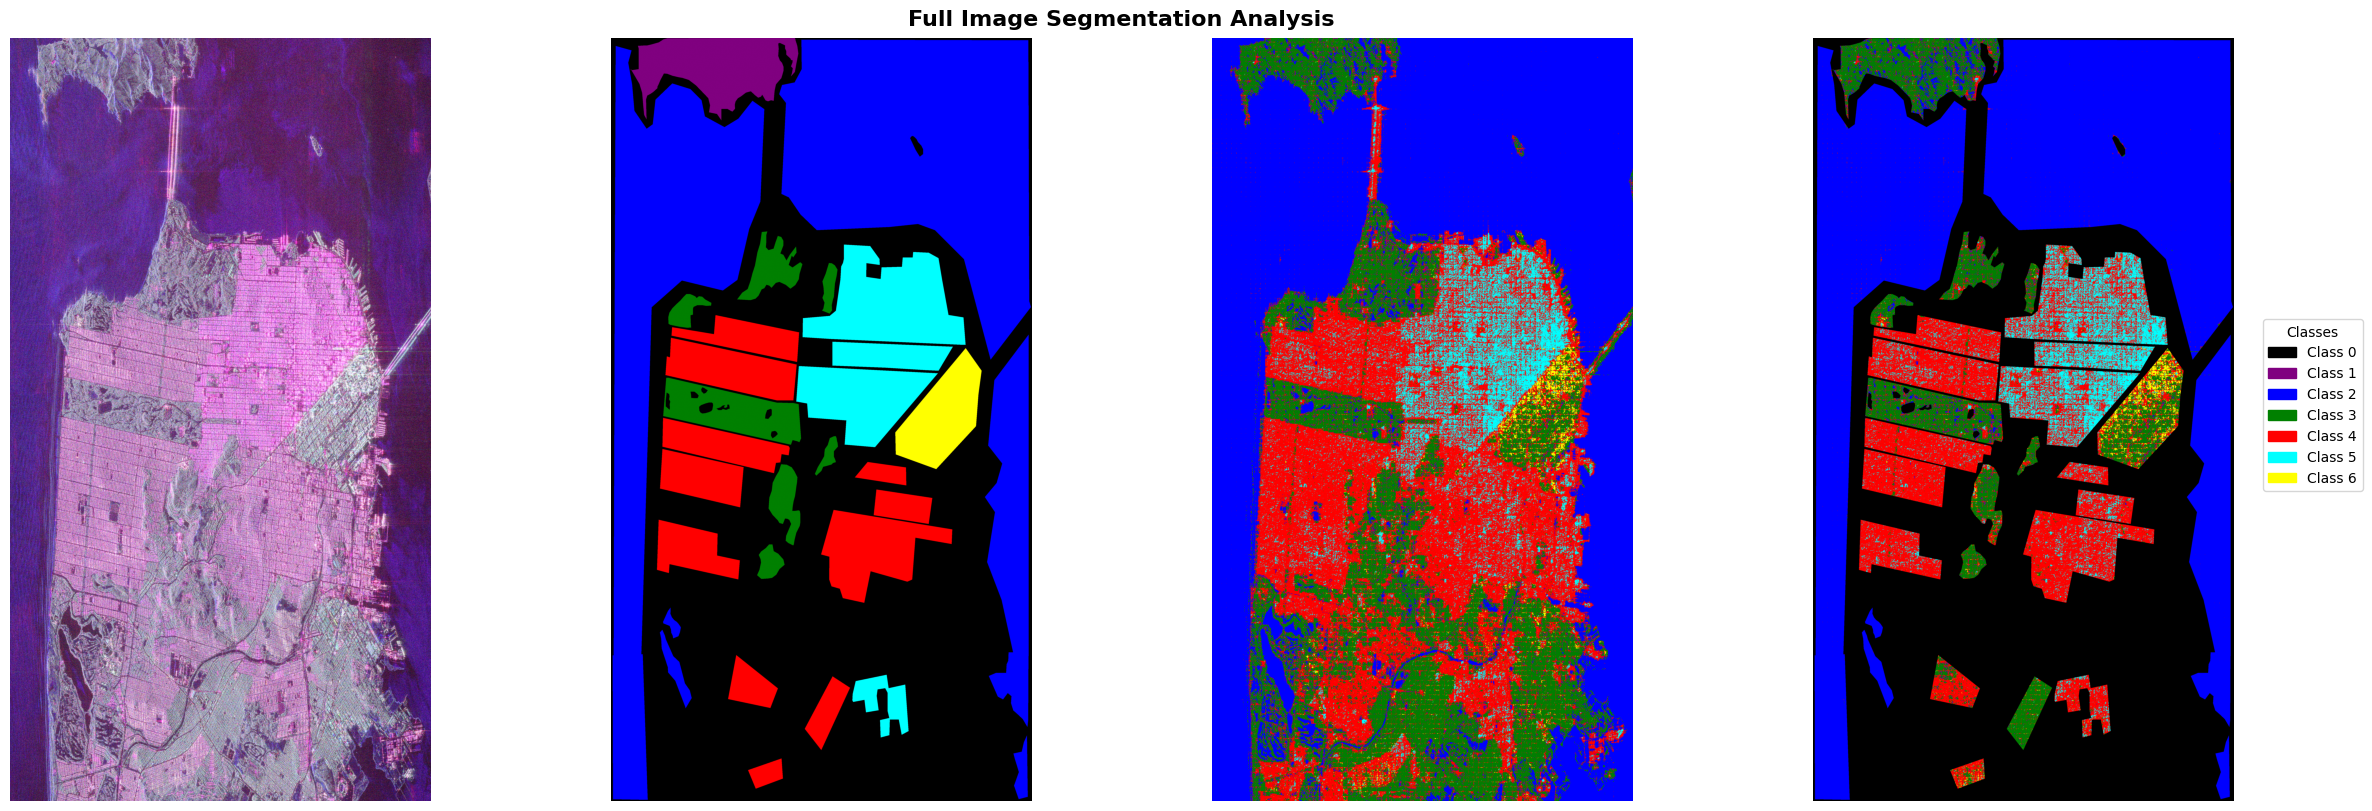

In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from cvnn.visualize import plot_segmentation_full_image

print("🗺️ Préparation de la reconstruction de la carte complète...")

# --- 1. RÉCUPÉRATION DU DATASET COMPLET ---
# On accède au dataset original (avant le découpage Train/Valid/Test)
base_dataset = train_loader.dataset.dataset

# Dans la librairie torchcvnn, PolSFDataset contient un objet alos_dataset avec les métadonnées
alos_dataset = base_dataset.alos_dataset
n_cols_patches = alos_dataset.nsamples_per_cols
n_rows_patches = alos_dataset.nsamples_per_rows
patch_size = cfg["data"]["dataset"]["patch_size"]

# Gestion de la taille du pas (stride) de la fenêtre glissante
if isinstance(alos_dataset.patch_stride, tuple):
    row_stride, col_stride = alos_dataset.patch_stride
else:
    row_stride = col_stride = alos_dataset.patch_stride

# --- 2. CALCUL DES DIMENSIONS TOTALES ---
full_height = (n_rows_patches - 1) * row_stride + patch_size
full_width = (n_cols_patches - 1) * col_stride + patch_size

print(f"📏 Taille estimée de San Francisco : {full_height} x {full_width} pixels")

# --- 3. CRÉATION DES TOILES VIERGES ---
# L'image radar brute [4 canaux, H, W]
full_image = np.zeros((4, full_height, full_width), dtype=np.complex64)
# La carte Ground Truth [H, W]
full_gt = np.zeros((full_height, full_width), dtype=np.int32)
# Les prédictions du modèle [H, W]
full_pred = np.zeros((full_height, full_width), dtype=np.int32)

# --- 4. LE SCAN (FENÊTRE GLISSANTE) ---
model.eval() # On s'assure que le modèle est en mode "test"
# On crée un DataLoader sur l'intégralité de la carte, SANS mélanger l'ordre !
full_loader = torch.utils.data.DataLoader(base_dataset, batch_size=1, shuffle=False)

print("⏳ Reconstitution de l'image en cours (le modèle scanne la baie de San Francisco)...")
with torch.no_grad():
    for idx, (x, y) in enumerate(full_loader):
        # Calcul des coordonnées de ce patch sur la carte finale
        row = (idx // n_cols_patches) * row_stride
        col = (idx % n_cols_patches) * col_stride
        
        # Le U-Net prédit le patch
        x_gpu = x.to(device, dtype=torch.complex64)
        output = model(x_gpu)
        pred = torch.argmax(torch.abs(output), dim=1).cpu().numpy()[0]
        
        # On "colle" les informations sur nos grandes toiles (x est de forme [1, 4, 256, 256])
        full_image[:, row:row+patch_size, col:col+patch_size] = x[0].numpy()
        full_gt[row:row+patch_size, col:col+patch_size] = y[0].numpy()
        full_pred[row:row+patch_size, col:col+patch_size] = pred

print("✅ Scan terminé ! Génération du dashboard visuel...")

# --- 5. AFFICHAGE AVEC CVNN ---
# La fonction prend en charge l'application de la décomposition de Pauli et le choix des couleurs
fig = plot_segmentation_full_image(
    ground_truth_segmentation=full_gt,
    predicted_segmentation=full_pred,
    original_image=full_image,
    dataset_type="polsar",
    number_classes=7,
    ignore_index=0   # Masque le fond (Unclassified) sur le dernier panneau
)

plt.show()